In [12]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [13]:
# Create DataFrame directly from the placement data
data = {
    'cgpa': [6.89, 5.12, 7.82, 7.42, 6.94, 7.89, 6.73, 6.75, 6.09, 8.31, 5.32, 6.61, 8.94, 6.93, 7.73, 7.25, 6.84, 5.38, 6.94, 7.37, 6.04, 7.63, 5.95, 6.53, 7.47, 6.96, 7.08, 5.25, 6.17, 6.13, 7.35, 6.32, 5.31, 8.32, 6.02, 7.16, 6.19, 5.56, 8.86, 7.49, 7.18, 8.18, 7.84, 6.65, 8.19, 6.86, 8.87, 5.78, 6.35, 6.32, 8.1, 6.14, 7.64, 7.94, 7.65, 7.86, 7.22, 6.81, 6.36, 7.83, 5.69, 7.99, 7.28, 6.8, 7.97, 5.89, 8.42, 5.36, 6.65, 8.15, 7.97, 7.27, 6.69, 6.25, 5.37, 7.63, 8.63, 5.94, 6.67, 8.49, 5.83, 7.32, 7.18, 7.86, 6.75, 6.12, 6.18, 6.89, 7.84, 5.32, 6.85, 6.86, 8.29, 7.96, 8.14, 8.24, 6.37, 6.42, 6.75, 6.81, 7.44, 5.29, 6.98, 7.36, 6.32, 5.43, 8.17, 5.62, 5.87, 6.84, 7.68, 7.25, 8.94, 8.87, 6.84, 8.99, 7.45, 5.14, 6.72, 7.35, 5.89, 5.83, 6.89, 6.82, 5.94, 7.31, 6.03, 7.34, 8.62, 7.44, 5.68, 6.34, 8.94, 8.78, 5.67, 8.32, 6.72, 6.15, 6.84, 7.95, 5.97, 7.34, 6.73, 6.85, 8.31, 6.75, 8.16, 7.63, 7.68, 8.86, 7.49, 6.34, 6.85, 8.87, 5.89, 6.32, 6.14, 8.1, 7.64, 7.94, 7.86, 8.19, 6.86, 5.78, 6.35, 7.22, 6.81, 7.83, 5.69, 7.99, 7.28, 6.8, 7.97, 5.89, 8.42, 5.36, 6.65, 8.15, 7.97, 7.27, 6.69, 6.25, 5.37, 7.63, 8.63, 5.94, 6.67, 8.49, 5.83, 7.32, 7.18, 7.86, 6.75, 6.12, 6.18, 6.89, 7.84, 5.32, 6.85, 6.86, 8.29, 7.96, 8.14, 8.24, 6.37, 6.42, 6.75, 6.81, 7.44, 5.29, 6.98, 7.36, 6.32, 5.43],
    'package': [3.26, 1.98, 3.25, 3.67, 3.57, 2.99, 2.6, 2.48, 2.31, 3.51, 1.86, 2.6, 3.65, 2.89, 3.42, 3.23, 2.35, 2.09, 2.98, 2.88, 2.24, 3.28, 2.59, 2.35, 3.23, 2.98, 3.16, 1.89, 2.29, 2.27, 3.15, 2.52, 1.87, 3.52, 2.22, 2.98, 2.14, 2.25, 3.86, 2.99, 3.18, 3.51, 3.84, 2.35, 3.19, 2.86, 3.87, 2.15, 2.53, 2.52, 3.1, 2.28, 3.29, 3.94, 3.3, 3.86, 3.22, 2.81, 2.54, 3.83, 2.17, 3.99, 3.28, 2.8, 3.97, 2.19, 3.42, 2.04, 2.65, 3.15, 3.97, 3.27, 2.69, 2.45, 2.05, 3.28, 3.63, 2.19, 2.67, 3.49, 2.18, 3.32, 3.18, 3.86, 2.75, 2.26, 2.28, 2.89, 3.84, 1.87, 2.85, 2.86, 3.29, 3.96, 3.14, 3.24, 2.55, 2.58, 2.75, 2.81, 3.44, 1.91, 2.98, 3.36, 2.52, 2.07, 3.17, 2.12, 2.17, 2.84, 3.68, 3.25, 3.65, 3.87, 2.84, 3.99, 3.45, 1.96, 2.72, 3.35, 2.19, 2.18, 2.89, 2.82, 2.19, 3.31, 2.23, 3.34, 3.62, 3.44, 2.16, 2.54, 3.65, 3.78, 2.15, 3.32, 2.72, 2.27, 2.84, 3.95, 2.21, 3.34, 2.73, 2.85, 3.31, 2.75, 3.16, 3.28, 3.68, 3.86, 3.49, 2.54, 2.85, 3.87, 2.19, 2.52, 2.28, 3.1, 3.29, 3.94, 3.86, 3.19, 2.86, 2.15, 2.53, 3.22, 2.81, 3.83, 2.17, 3.99, 3.28, 2.8, 3.97, 2.19, 3.42, 2.04, 2.65, 3.15, 3.97, 3.27, 2.69, 2.45, 2.05, 3.28, 3.63, 2.19, 2.67, 3.49, 2.18, 3.32, 3.18, 3.86, 2.75, 2.26, 2.28, 2.89, 3.84, 1.87, 2.85, 2.86, 3.29, 3.96, 3.14, 3.24, 2.55, 2.58, 2.75, 2.81, 3.44, 1.91, 2.98, 3.36, 2.52, 2.07]
}
df = pd.DataFrame(data)

In [14]:
df.head()

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


Text(0, 0.5, 'Package(in lpa)')

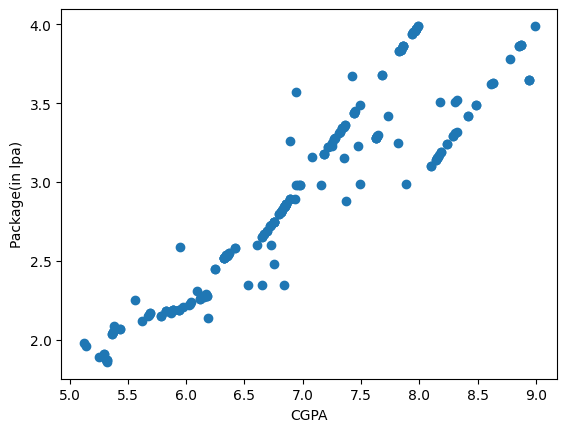

In [15]:
plt.scatter(df['cgpa'],df['package'])
plt.xlabel('CGPA')
plt.ylabel('Package(in lpa)')

In [16]:
X = df.iloc[:,0:1]
y = df.iloc[:,-1]

In [17]:
y

0      3.26
1      1.98
2      3.25
3      3.67
4      3.57
       ... 
209    1.91
210    2.98
211    3.36
212    2.52
213    2.07
Name: package, Length: 214, dtype: float64

In [18]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [19]:
from sklearn.linear_model import LinearRegression

In [20]:
lr = LinearRegression()

In [21]:
lr.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [22]:
X_test

,cgpa
23,6.53
155,6.32
207,6.81
13,6.93
64,7.97
131,6.34
141,7.34
193,6.12
93,7.96
30,7.35


In [23]:
y_test

23     2.35
155    2.52
207    2.81
13     2.89
64     3.97
131    2.54
141    3.34
193    2.26
93     3.96
30     3.15
10     1.86
89     1.87
176    2.65
65     2.19
139    3.95
35     2.98
71     3.27
142    2.73
25     2.98
196    3.84
201    3.96
134    2.15
165    3.22
44     3.19
192    2.75
211    3.36
154    2.19
153    3.87
53     3.94
24     3.23
133    3.78
186    2.67
112    3.65
84     2.75
6      2.60
28     2.29
12     3.65
29     2.27
122    2.89
18     2.98
41     3.51
5      2.99
183    3.28
Name: package, dtype: float64

In [24]:
lr.predict(X_test.iloc[0].values.reshape(1,1))

C:\Users\Raghav\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([2.65820748])

Text(0, 0.5, 'Package(in lpa)')

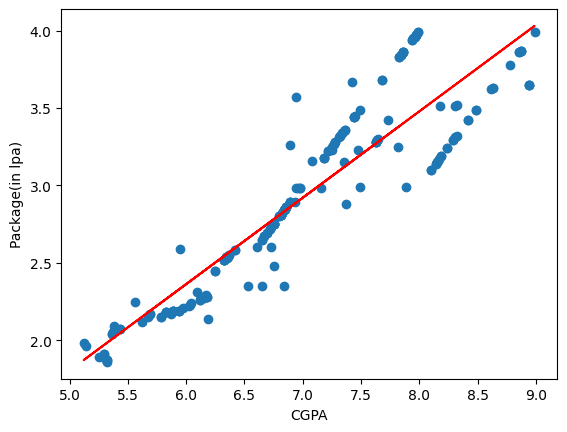

In [25]:
plt.scatter(df['cgpa'],df['package'])
plt.plot(X_train,lr.predict(X_train),color='red')
plt.xlabel('CGPA')
plt.ylabel('Package(in lpa)')

In [26]:
m = lr.coef_

In [27]:
b = lr.intercept_

In [28]:
# y = mx + b

m * 8.58 + b

array([3.80114313])

In [29]:
m * 9.5 + b

array([4.31407035])

In [30]:
m * 100 + b

array([54.77049785])